# Stability Check (Judgement Call)

This notebook conducts stability check based on the following 4 preprocessing judgement calls:

1. raw
2. standardize
3. sigma3
4. standardize_sigma3

In [1]:
import stability_judgement_call as sjc

IMAGE_IDS = ["O012791", "O013257", "O013490"]
TRAIN_IMAGE_IDS = ["O012791", "O013257"]
TEST_IMAGE_ID = "O013490"
WORK_DIR = "../data/stability_judgement_call"
MODEL_DIR = "../results/stability_judgement_call"

In [2]:
summary = sjc.preprocess_npz_files(
    image_ids=IMAGE_IDS,
    train_image_ids=TRAIN_IMAGE_IDS,
    source_dir="../data",
    output_dir=WORK_DIR,
    sigma_threshold=3.0,
)

print(summary.to_string(index=False))

              mode image_id  n_before  n_after  n_dropped  drop_rate
               raw  O012791    114973   114973          0   0.000000
               raw  O013257    115000   115000          0   0.000000
               raw  O013490    115032   115032          0   0.000000
            sigma3  O012791    114973   108559       6414   0.055787
            sigma3  O013257    115000   107514       7486   0.065096
            sigma3  O013490    115032   102657      12375   0.107579
       standardize  O012791    114973   114973          0   0.000000
       standardize  O013257    115000   115000          0   0.000000
       standardize  O013490    115032   115032          0   0.000000
standardize_sigma3  O012791    114973   108559       6414   0.055787
standardize_sigma3  O013257    115000   107514       7486   0.065096
standardize_sigma3  O013490    115032   102657      12375   0.107579


In [2]:
# run the process for stability check on judgement call
result = sjc.run_full_experiment(
    image_ids=IMAGE_IDS,
    train_image_ids=TRAIN_IMAGE_IDS,
    test_image_id=TEST_IMAGE_ID,
    source_dir="../data",
    work_dir=WORK_DIR,
    model_dir=MODEL_DIR,
    config_path="configs/exp_028_finetune.yaml",
    weights_path="../results/exp_028/exp_028_finetune.pt",
    sigma_threshold=3.0,
    top_n_features=105,
    n_estimators=1000,
    excluded_prefixes=["AF_", "BF_", "CF_", "DF_", "AN_"],
)


mode: raw
Loading the saved model
Making the patch data
done reshaping images
working on image 0
Obtaining embeddings


100%|██████████| 3/3 [00:30<00:00, 10.04s/it]


Saving the embeddings


merging and saving: 100%|██████████| 3/3 [00:12<00:00,  4.17s/it]


Fitting 8 folds for each of 9 candidates, totalling 72 fits
Best parameters: {'learning_rate': 0.15, 'num_leaves': 31}
Best CV score: 0.9276
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     42830
         1.0       0.97      1.00      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083

Accuracy: 0.9875248224358272

mode: standardize
Loading the saved model
Making the patch data
done reshaping images
working on image 0
Obtaining embeddings


...

Fitting 8 folds for each of 9 candidates, totalling 72 fits
Best parameters: {'learning_rate': 0.15, 'num_leaves': 15}
Best CV score: 0.9356
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     41700
         1.0       0.97      1.00      0.98     29290

    accuracy                           0.98     70990
   macro avg       0.98      0.99      0.98     70990
weighted avg       0.99      0.98      0.98     70990

Accuracy: 0.9848288491336809

mode: standardize_sigma3
Loading the saved model
Making the patch data
done reshaping images
working on image 0
Obtaining embeddings


100%|██████████| 3/3 [00:24<00:00,  8.27s/it]


Saving the embeddings


merging and saving: 100%|██████████| 3/3 [00:11<00:00,  3.81s/it]


Fitting 8 folds for each of 9 candidates, totalling 72 fits
Best parameters: {'learning_rate': 0.15, 'num_leaves': 15}
Best CV score: 0.9324
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     41700
         1.0       0.98      0.99      0.98     29290

    accuracy                           0.99     70990
   macro avg       0.99      0.99      0.99     70990
weighted avg       0.99      0.99      0.99     70990

Accuracy: 0.9866037470066207


In [3]:
metrics_df = result["metrics_df"]
print(metrics_df.sort_values("roc_auc", ascending=False).to_string(index=False))

              mode  n_train  n_test  accuracy  precision   recall       f1  roc_auc  cv_best_score
       standardize   125598   82083  0.988719   0.977001 0.999949 0.988342 0.998884       0.927331
               raw   125598   82083  0.987525   0.974576 1.000000 0.987124 0.998074       0.927557
standardize_sigma3   120449   70990  0.986604   0.976558 0.991328 0.983888 0.997350       0.932361
            sigma3   120449   70990  0.984829   0.967242 0.996996 0.981893 0.996296       0.935587


ROC figure saved: ../figs/stability_judgement_call_roc.png


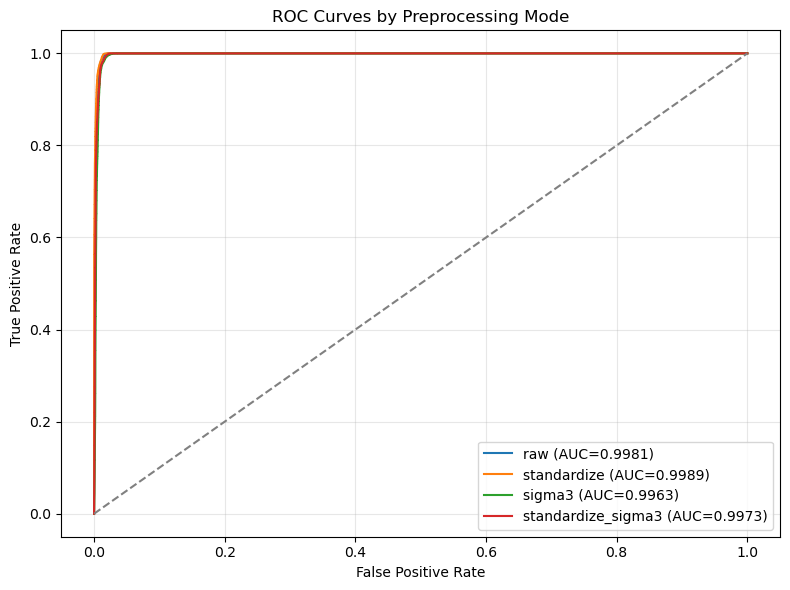

In [4]:
# Visualize ROC curves by modes
sjc.plot_roc_curves(
    result["results_by_mode"],
    title="ROC Curves by Preprocessing Mode",
    save_path="../figs/stability_judgement_call_roc.png",
)